In [2]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_75636/112696078.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_provider["date_time"] = df_provider["date_time"].str[0:10]
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_75636/112696078.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Memory")
/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_75636/112696078.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

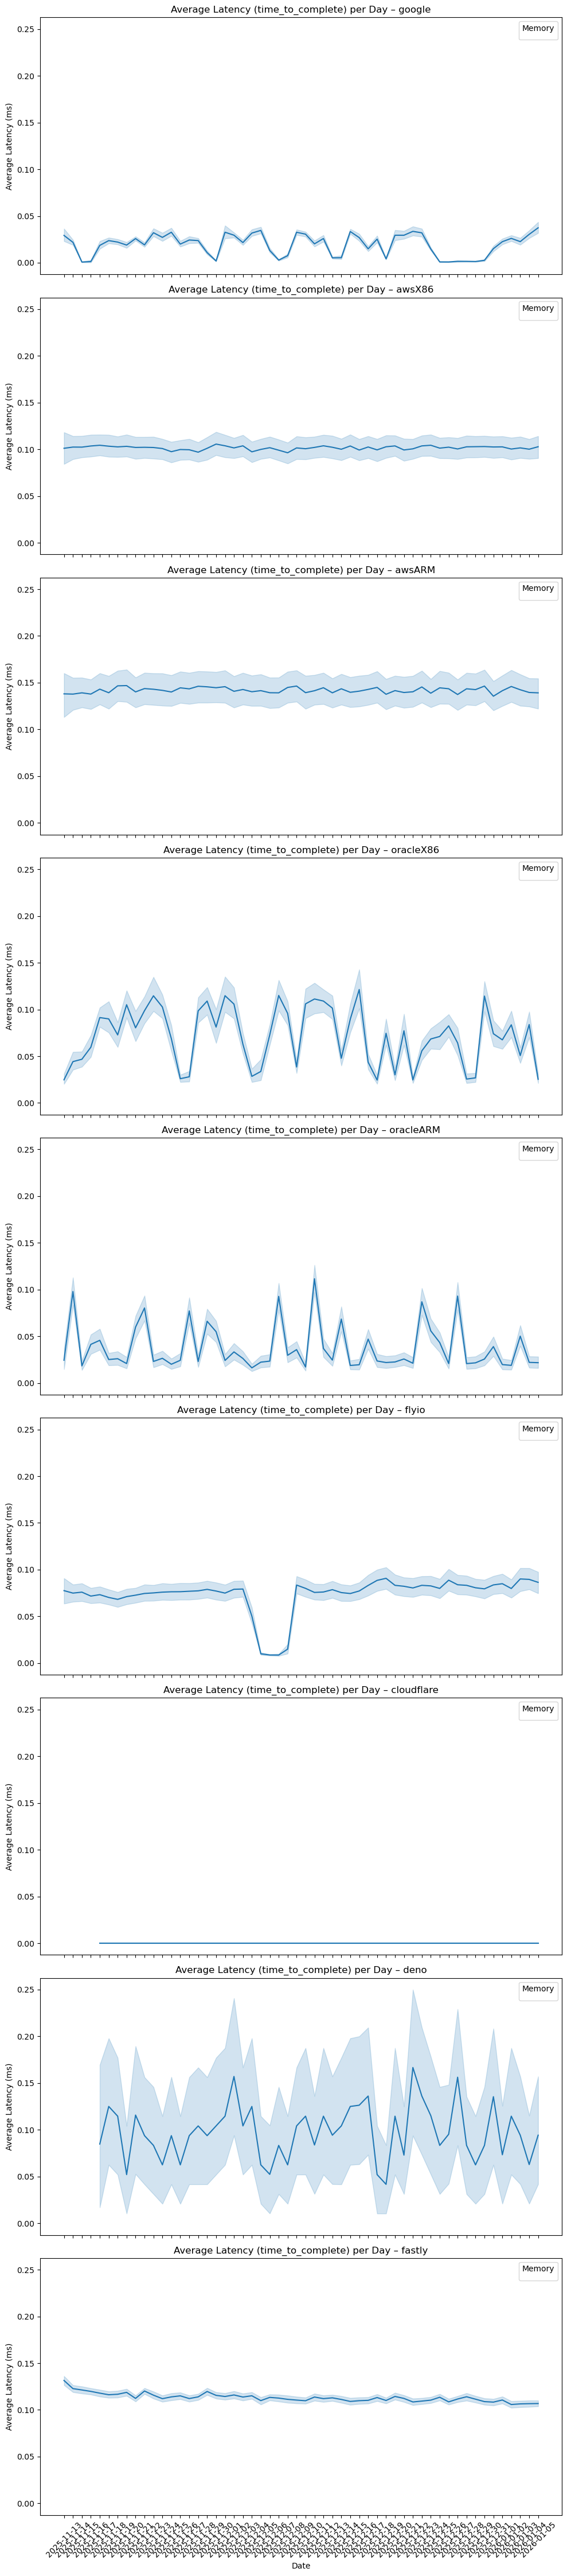

In [4]:
# Take a look at io performance over time

# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "flyio", "cloudflare", "deno", "fastly"]  # <-- edit this list

# Number of subplots
n_providers = len(providers)

fig, axes = plt.subplots(
    nrows=n_providers,
    ncols=1,
    figsize=(10, 5 * n_providers),
    sharex=True,
    sharey=True
)

# If only one provider, axes is not iterable
if n_providers == 1:
    axes = [axes]
    
df = pd.read_sql("select * from data where experiment = 'cpu'", cnx) 

for ax, provider in zip(axes, providers):
    df_provider = df[df["provider"] == provider]
    df_provider["date_time"] = df_provider["date_time"].str[0:10]

    p99 = df_provider["time_to_complete"].quantile(0.99)
    df_provider = df_provider[df_provider["time_to_complete"] <= p99]
    
    sns.lineplot(
        data=df_provider,
        x="date_time",
        y="time_to_complete",
        ax=ax
    )

    ax.set_title(f"Average Latency (time_to_complete) per Day – {provider}")
    ax.set_ylabel("Average Latency (ms)")
    ax.legend(title="Memory")

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

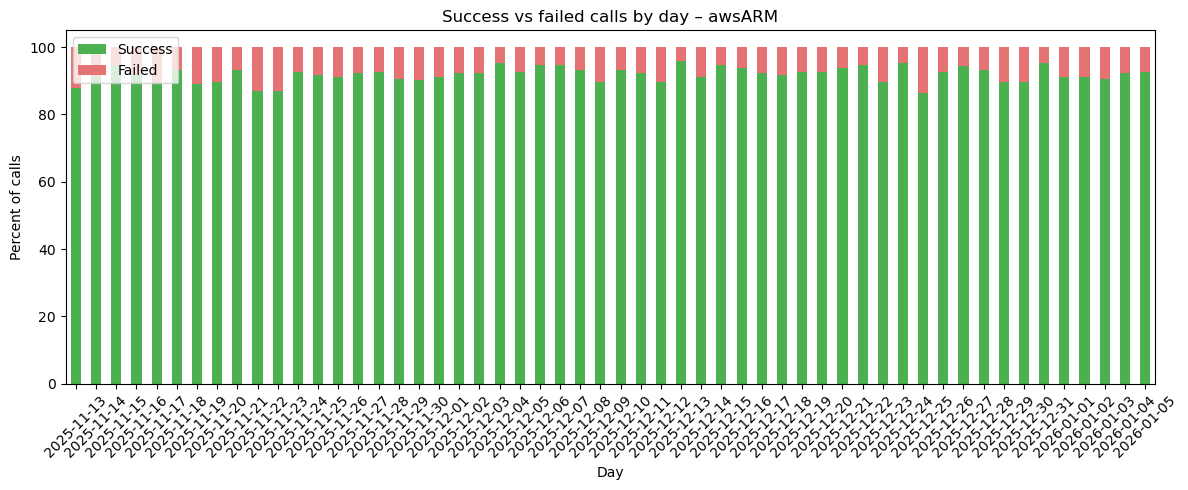

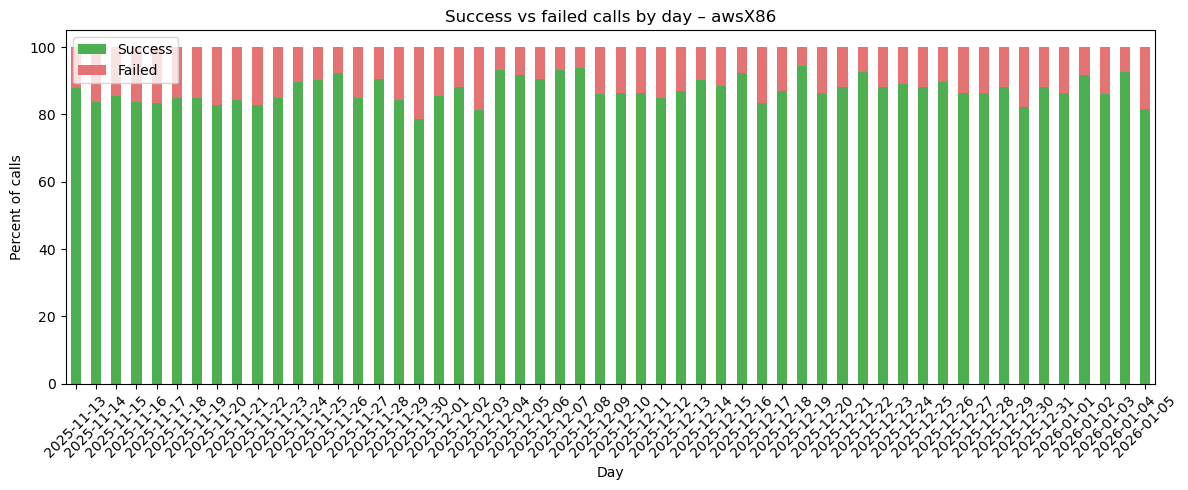

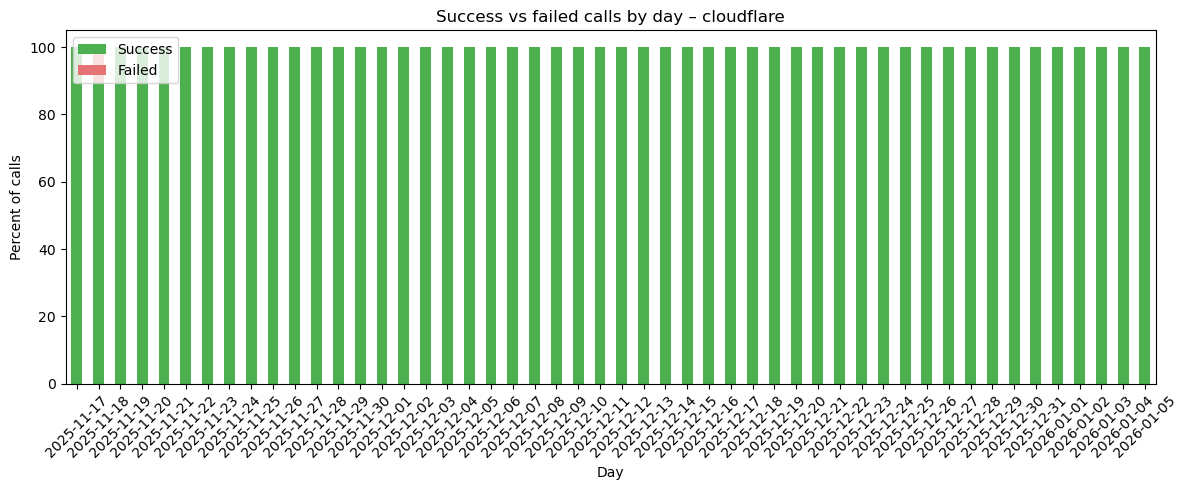

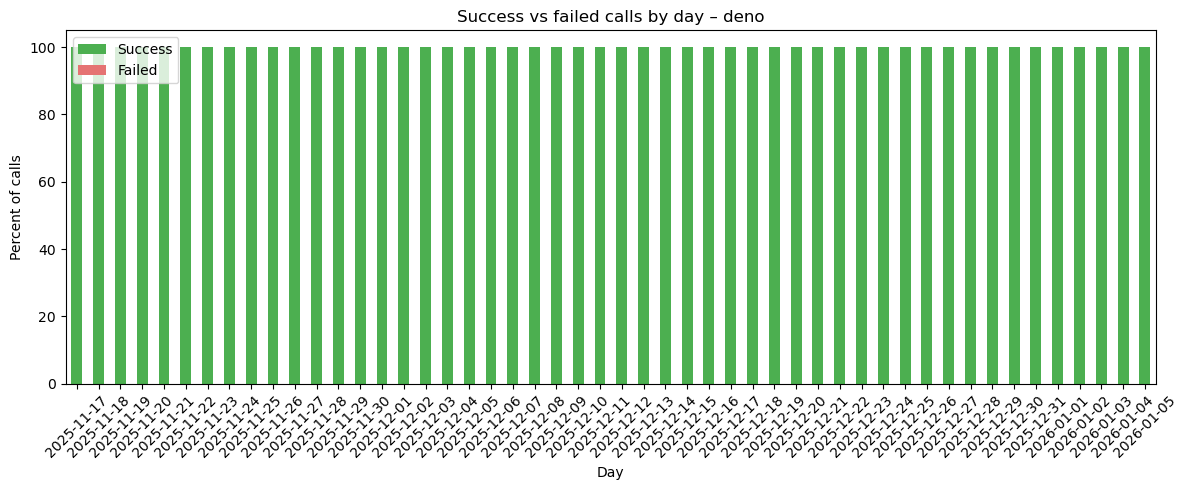

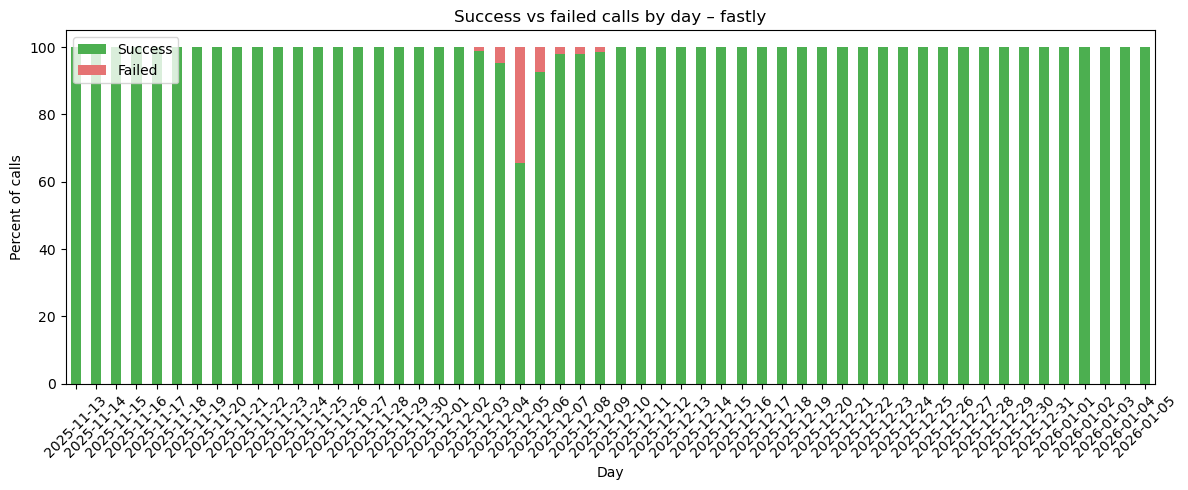

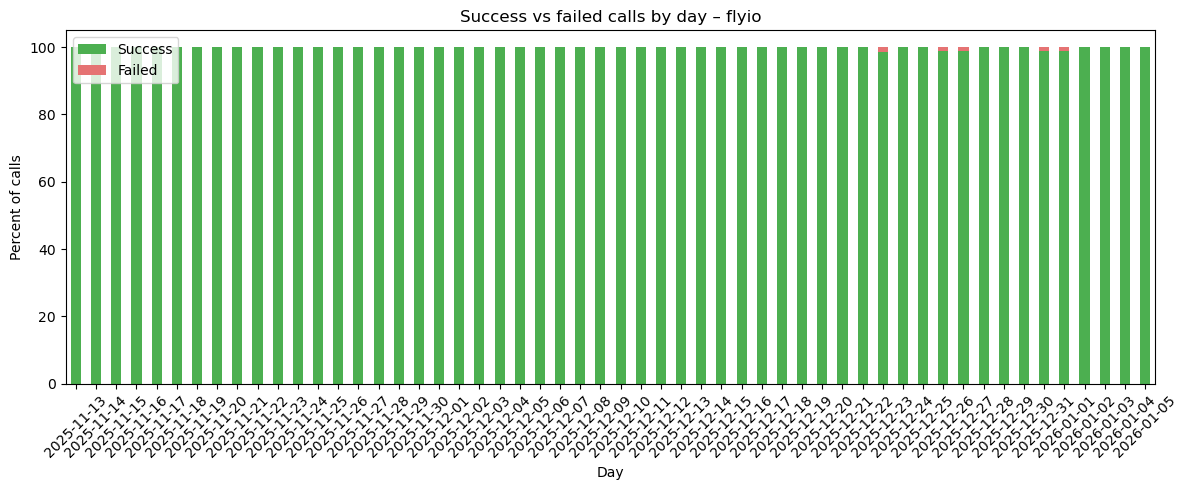

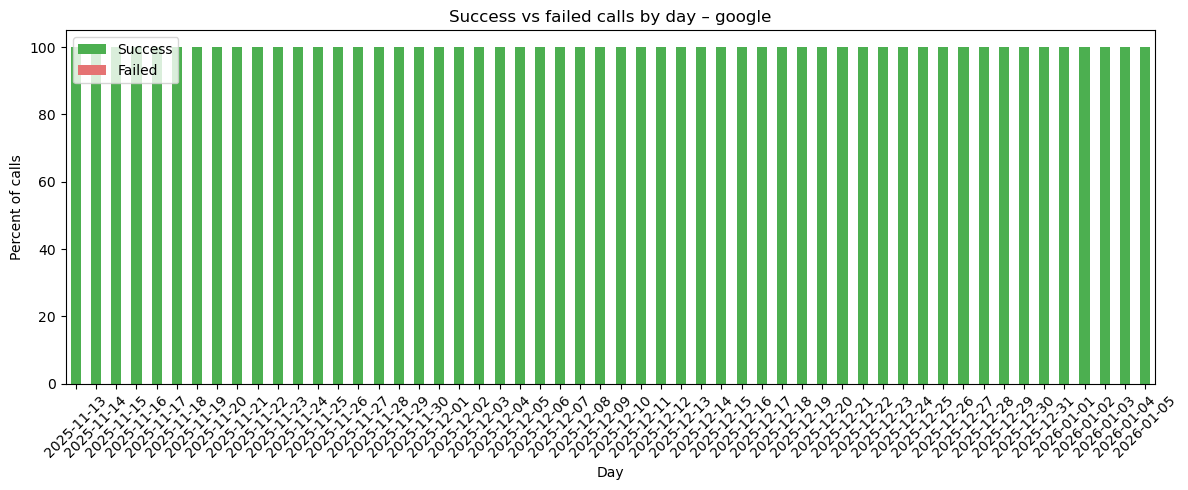

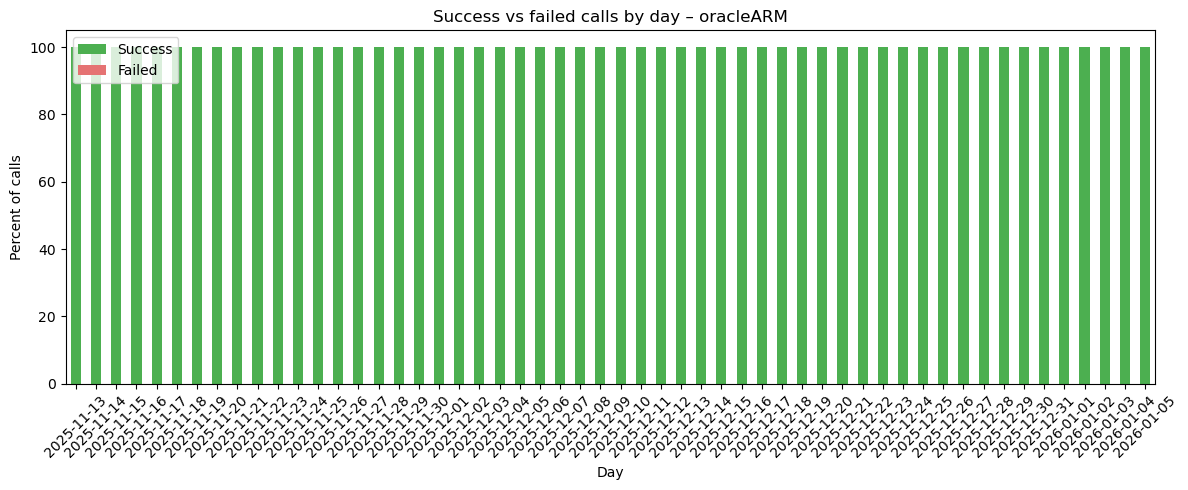

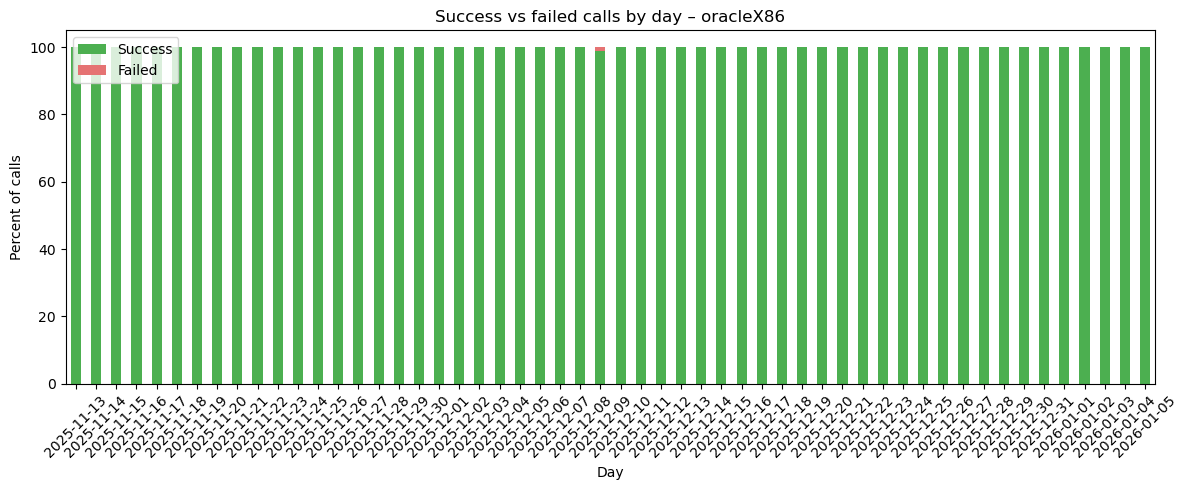

In [8]:
# Check missing data per day with success vs failure ratios (one chart per provider)

# Total calls per day/provider
df_total = pd.read_sql_query("""
    SELECT
        substr(date_time, 1, 10) AS day,
        provider,
        COUNT(*) AS total_count
    FROM data
    WHERE experiment = 'cpu'
    GROUP BY day, provider
""", cnx)

# Missing time_to_complete per day/provider
df_null = pd.read_sql_query("""
    SELECT
        substr(date_time, 1, 10) AS day,
        provider,
        COUNT(*) AS null_count
    FROM data
    WHERE experiment = 'cpu'
      AND time_to_complete IS NULL
    GROUP BY day, provider
""", cnx)

# Merge and compute success/failure counts and percentages
df = df_total.merge(df_null, on=["day", "provider"], how="left")
df["null_count"] = df["null_count"].fillna(0)
df["success_count"] = df["total_count"] - df["null_count"]
df["fail_pct"] = 100.0 * df["null_count"] / df["total_count"]
df["success_pct"] = 100.0 * df["success_count"] / df["total_count"]

providers = sorted(df["provider"].unique())

for provider in providers:
    df_p = df[df["provider"] == provider].copy()
    if df_p.empty:
        continue

    df_p = df_p.sort_values("day")
    plot_df = df_p.set_index("day")[["success_pct", "fail_pct"]]

    # Stacked percentage bars per day for this provider
    plot_df.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#4CAF50", "#E57373"])
    plt.title(f"Success vs failed calls by day – {provider}")
    plt.xlabel("Day")
    plt.ylabel("Percent of calls")
    plt.xticks(rotation=45)
    plt.legend(["Success", "Failed"], loc="upper left")
    plt.tight_layout()
    plt.show()